# Bay Area Multifamily: Distressed Operator Signal Detection

**Goal:** Identify San Francisco neighborhoods and zip codes where multifamily operators show signs of financial or operational distress — creating potential off-market acquisition opportunities.

**Data sources:**
- SF Eviction notices (city open data, 2021–2026)
- SF Building permits (residential, last 5 years — deferred maintenance signal)
- Zillow price cuts by zip (seller desperation)
- Census ACS: vacancy rates, rent burden

**Distress signals:**
| Signal | What it means |
|--------|---------------|
| High eviction rate | Operator struggling with rent collection / tenant issues |
| Ellis Act withdrawals | Owner exiting the rental market entirely |
| Owner move-in evictions | Owner liquidating / repositioning |
| Low permit activity | Deferred maintenance = capital constrained operator |
| High price cuts | Motivated sellers in the market |
| High vacancy + high rent burden | Structural stress in the submarket |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import folium
import json
import requests
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data/raw')
OUT  = Path('../outputs')
(OUT / 'maps').mkdir(exist_ok=True)
(OUT / 'charts').mkdir(exist_ok=True)
(OUT / 'tables').mkdir(exist_ok=True)

## 1. SF Eviction Analysis

In [2]:
ev = pd.read_csv(DATA / 'sf_evictions.csv')
ev['file_date'] = pd.to_datetime(ev['file_date'])
ev['year'] = ev['file_date'].dt.year
ev['zip'] = ev['zip'].astype(str).str.strip().str[:5]

print(f'Total evictions in dataset: {len(ev):,}')
print(f'Date range: {ev["file_date"].min().date()} → {ev["file_date"].max().date()}')
print(f'\nUnique neighborhoods: {ev["neighborhood"].nunique()}')
print(f'Unique zips: {ev["zip"].nunique()}')

# Eviction reason breakdown
reason_cols = [
    'non_payment','breach','nuisance','illegal_use','failure_to_sign_renewal',
    'access_denial','unapproved_subtenant','owner_move_in','demolition',
    'capital_improvement','substantial_rehab','ellis_act_withdrawal',
    'condo_conversion','other_cause','late_payments','development'
]

# Convert boolean strings to actual booleans
for col in reason_cols:
    if col in ev.columns:
        ev[col] = ev[col].map({'True': True, 'False': False, True: True, False: False})

reason_counts = ev[reason_cols].sum().sort_values(ascending=False)
print('\nEviction reasons (total):')
print(reason_counts)

Total evictions in dataset: 5,794
Date range: 2021-06-01 → 2026-05-28

Unique neighborhoods: 39
Unique zips: 37

Eviction reasons (total):
nuisance                   1868
non_payment                1350
breach                      950
capital_improvement         446
owner_move_in               399
ellis_act_withdrawal        240
unapproved_subtenant        134
other_cause                 110
demolition                   83
access_denial                42
late_payments                34
illegal_use                  29
failure_to_sign_renewal       3
condo_conversion              3
development                   1
substantial_rehab             0
dtype: int64


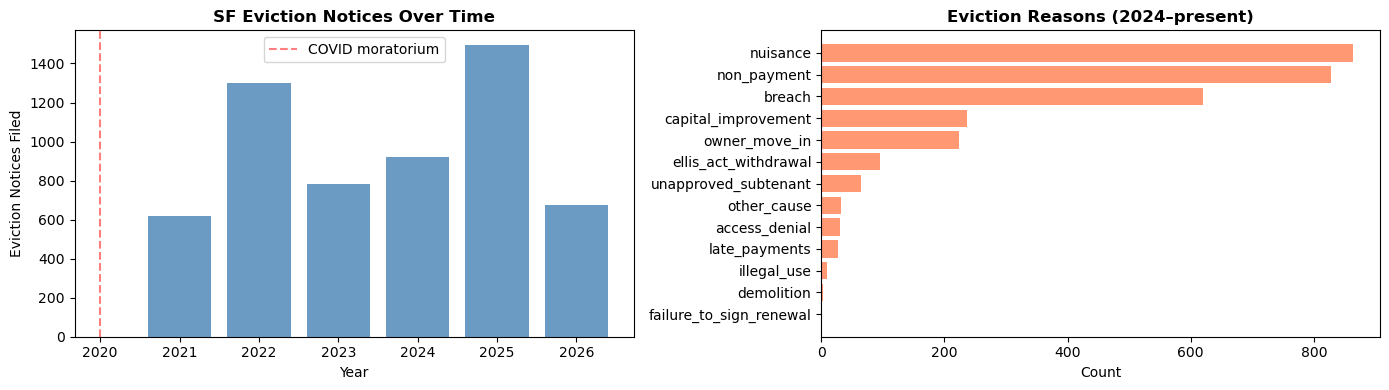

In [3]:
# Evictions over time
annual = ev.groupby('year').size().reset_index(name='evictions')
annual = annual[annual['year'] >= 2015]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(annual['year'], annual['evictions'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Eviction Notices Filed')
axes[0].set_title('SF Eviction Notices Over Time', fontweight='bold')
axes[0].axvline(2020, color='red', linestyle='--', alpha=0.5, label='COVID moratorium')
axes[0].legend()

# Reason breakdown for most recent 2 years
recent_ev = ev[ev['year'] >= 2024]
recent_reasons = recent_ev[reason_cols].sum().sort_values(ascending=True)
recent_reasons = recent_reasons[recent_reasons > 0]
axes[1].barh(recent_reasons.index, recent_reasons.values, color='coral', alpha=0.8)
axes[1].set_xlabel('Count')
axes[1].set_title('Eviction Reasons (2024–present)', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'charts/evictions_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Neighborhood-level eviction heatmap
recent_ev = ev[ev['year'] >= 2022].copy()

# Distressed eviction signals: non-payment, breach, late payments = financial distress
# Ellis Act, owner move-in = operator exiting market
recent_ev['operator_distress'] = (
    recent_ev[['non_payment','breach','late_payments']]
    .apply(lambda x: x.fillna(False)).any(axis=1)
).astype(int)

recent_ev['owner_exit'] = (
    recent_ev[['ellis_act_withdrawal','owner_move_in','demolition']]
    .apply(lambda x: x.fillna(False)).any(axis=1)
).astype(int)

nbhd = recent_ev.groupby('neighborhood').agg(
    total_evictions=('eviction_id','count'),
    operator_distress=('operator_distress','sum'),
    owner_exits=('owner_exit','sum'),
    non_payment=('non_payment','sum'),
    ellis_act=('ellis_act_withdrawal','sum'),
    owner_move_in=('owner_move_in','sum'),
).sort_values('total_evictions', ascending=False)

nbhd['distress_pct'] = nbhd['operator_distress'] / nbhd['total_evictions']
nbhd['exit_pct'] = nbhd['owner_exits'] / nbhd['total_evictions']

print('Top 15 neighborhoods by eviction activity (2022-present):')
display(nbhd.head(15))

Top 15 neighborhoods by eviction activity (2022-present):


,total_evictions,operator_distress,owner_exits,non_payment,ellis_act,owner_move_in,distress_pct,exit_pct
neighborhood,,,,,,,,
Tenderloin,724,390,2,230,0,2,0.538674,0.002762
Financial District/South Beach,705,347,62,286,0,1,0.492199,0.087943
Mission,555,175,66,89,29,37,0.315315,0.118919
South of Market,320,158,6,93,0,1,0.493750,0.018750
Nob Hill,261,86,7,37,4,3,0.329502,0.026820
Sunset/Parkside,203,46,83,17,32,51,0.226601,0.408867
Outer Richmond,180,38,61,19,23,38,0.211111,0.338889
Western Addition,170,100,5,78,2,3,0.588235,0.029412
Bayview Hunters Point,161,65,31,35,6,25,0.403727,0.192547


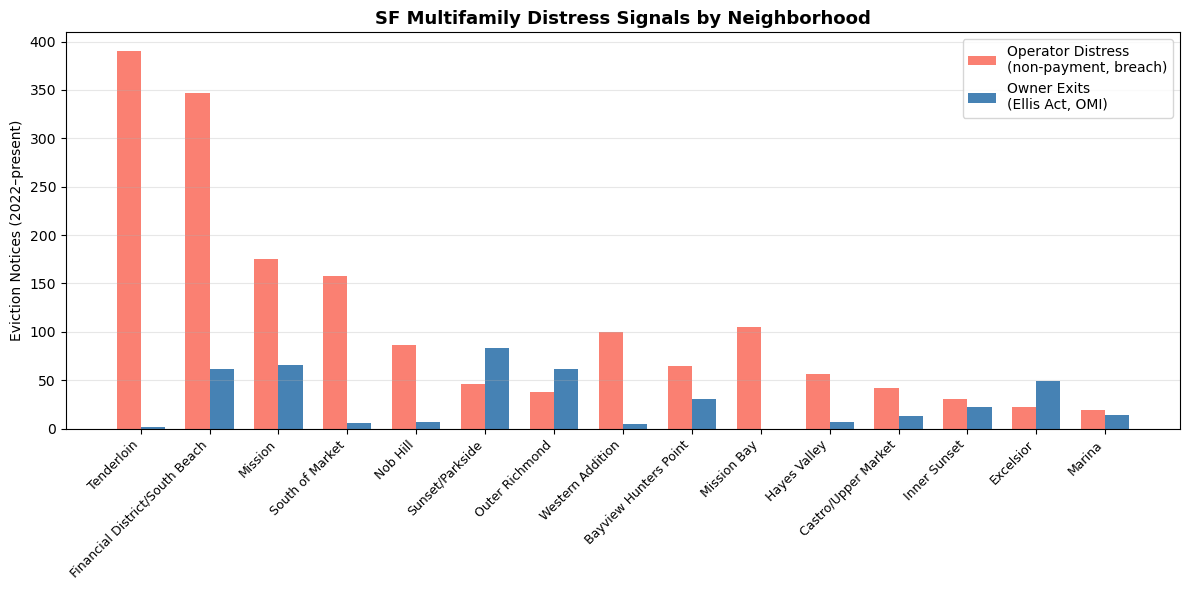

In [5]:
# Neighborhood bar chart
top_nbhd = nbhd.head(15)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(top_nbhd))
w = 0.35

bars1 = ax.bar(x - w/2, top_nbhd['operator_distress'], w, label='Operator Distress\n(non-payment, breach)', color='salmon')
bars2 = ax.bar(x + w/2, top_nbhd['owner_exits'], w, label='Owner Exits\n(Ellis Act, OMI)', color='steelblue')

ax.set_xticks(x)
ax.set_xticklabels(top_nbhd.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Eviction Notices (2022–present)')
ax.set_title('SF Multifamily Distress Signals by Neighborhood', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'charts/evictions_by_neighborhood.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Ellis Act Withdrawals — Owner Exit Signal

Ellis Act allows landlords to exit the rental business entirely. High Ellis Act activity = owners giving up on a building.

Total Ellis Act withdrawals: 240


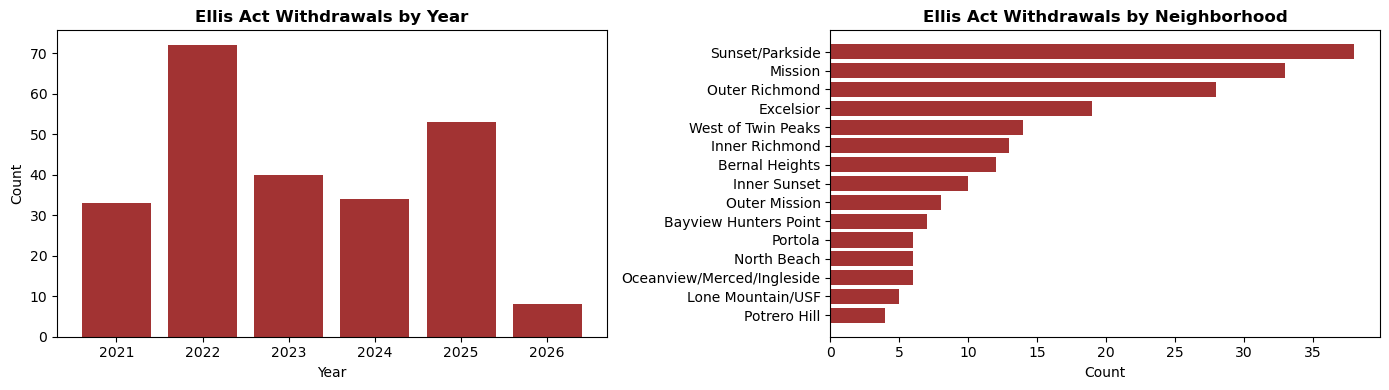


Key insight: Ellis Act clustered in specific neighborhoods signals concentrated owner fatigue


In [6]:
ellis = ev[ev['ellis_act_withdrawal'] == True].copy()
print(f'Total Ellis Act withdrawals: {len(ellis)}')

ellis_annual = ellis.groupby('year').size()
ellis_nbhd = ellis.groupby('neighborhood').size().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(ellis_annual.index, ellis_annual.values, color='darkred', alpha=0.8)
axes[0].set_xlabel('Year')
axes[0].set_title('Ellis Act Withdrawals by Year', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].barh(ellis_nbhd.index[::-1], ellis_nbhd.values[::-1], color='darkred', alpha=0.8)
axes[1].set_title('Ellis Act Withdrawals by Neighborhood', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(OUT / 'charts/ellis_act.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey insight: Ellis Act clustered in specific neighborhoods signals concentrated owner fatigue')

## 3. Building Permit Analysis — Deferred Maintenance Signal

In [7]:
permits = pd.read_csv(DATA / 'sf_permits.csv', low_memory=False)
permits['filed_date'] = pd.to_datetime(permits['filed_date'], errors='coerce')
permits['year'] = permits['filed_date'].dt.year

print(f'Total permits: {len(permits):,}')
print(f'Date range: {permits["filed_date"].min().date()} → {permits["filed_date"].max().date()}')
print(f'\nPermit type breakdown:')
print(permits['permit_type_definition'].value_counts().head(10))

Total permits: 50,000
Date range: 2021-06-01 → 2023-05-31

Permit type breakdown:
permit_type_definition
otc alterations permit                 45199
additions alterations or repairs        3388
sign - erect                             708
new construction wood frame              246
demolitions                              188
wall or painted sign                     170
new construction                          82
grade or quarry or fill or excavate       19
Name: count, dtype: int64


In [8]:
# Focus on alterations/repairs (deferred maintenance indicator when ABSENT)
# A building with no permits pulled in 5+ years = likely deferred maintenance
repair_types = ['alterations', 'repair', 'residential']
repair_mask = permits['permit_type_definition'].str.lower().str.contains(
    '|'.join(repair_types), na=False
)
repair_permits = permits[repair_mask].copy()

# Permits by neighborhood / zip
if 'neighborhoods_analysis_boundaries' in repair_permits.columns:
    nbhd_permits = repair_permits.groupby('neighborhoods_analysis_boundaries')['permit_number'].count()
    nbhd_col = 'neighborhoods_analysis_boundaries'
elif 'supervisor_district' in repair_permits.columns:
    nbhd_permits = repair_permits.groupby('supervisor_district')['permit_number'].count()
    nbhd_col = 'supervisor_district'
else:
    nbhd_col = None

# Recent permits (2023-present) as % of total — low recent % = deferred maintenance
recent_permits = repair_permits[repair_permits['year'] >= 2023]
total_by_zip = repair_permits.groupby('zipcode')['permit_number'].count() if 'zipcode' in repair_permits.columns else pd.Series(dtype=int)
recent_by_zip = recent_permits.groupby('zipcode')['permit_number'].count() if 'zipcode' in repair_permits.columns else pd.Series(dtype=int)

if not total_by_zip.empty:
    permit_ratio = (recent_by_zip / total_by_zip).fillna(0)
    low_permit_zips = permit_ratio.sort_values().head(10)
    print('Zip codes with lowest recent permit activity (potential deferred maintenance):')
    print(low_permit_zips)
else:
    print('Zip code column not found in permit data — checking available columns:')
    addr_cols = [c for c in repair_permits.columns if any(x in c.lower() for x in ['zip','postal','addr'])]
    print(addr_cols[:5])
    print(repair_permits.columns.tolist()[:20])

Zip codes with lowest recent permit activity (potential deferred maintenance):
zipcode
94158.0    0.115756
94104.0    0.152632
94105.0    0.153303
94111.0    0.153904
94102.0    0.166531
94133.0    0.177481
94103.0    0.179614
94107.0    0.184092
94117.0    0.189110
94116.0    0.191204
Name: permit_number, dtype: float64


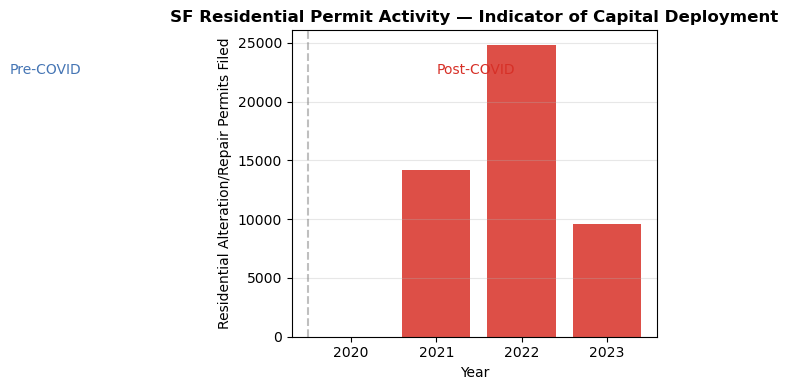

In [9]:
# Permit volume over time — pre vs post COVID
annual_permits = repair_permits[repair_permits['year'] >= 2015].groupby('year').size()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d73027' if y >= 2020 else '#4575b4' for y in annual_permits.index]
ax.bar(annual_permits.index, annual_permits.values, color=colors, alpha=0.85)
ax.axvline(2019.5, color='gray', linestyle='--', alpha=0.5)
ax.text(2016, annual_permits.max()*0.9, 'Pre-COVID', fontsize=10, color='#4575b4')
ax.text(2021, annual_permits.max()*0.9, 'Post-COVID', fontsize=10, color='#d73027')
ax.set_xlabel('Year')
ax.set_ylabel('Residential Alteration/Repair Permits Filed')
ax.set_title('SF Residential Permit Activity — Indicator of Capital Deployment', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'charts/permits_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Composite Distress Score by Zip

In [10]:
# Load market selection data and Census data (for renter unit counts)
mkt = pd.read_csv(OUT / 'tables/market_selection_ranked.csv', dtype={'zip_code': str})
census = pd.read_csv(DATA / 'census_acs_zip.csv', dtype={'zip_code': str})

# Eviction rate by zip (recent 3 years)
recent_ev_zip = ev[ev['year'] >= 2022].groupby('zip').agg(
    eviction_count=('eviction_id','count'),
    non_payment_count=('non_payment','sum'),
    ellis_count=('ellis_act_withdrawal','sum'),
    owner_exit_count=('owner_move_in','sum'),
).reset_index()
recent_ev_zip.columns = ['zip_code','eviction_count','non_payment_count','ellis_count','owner_exit_count']

# Merge with market data + census renter unit count
distress = mkt[['zip_code','City','CountyName','investment_score',
                  'vacancy_rate','price_cut_rate']].copy()
distress = distress.merge(
    census[['zip_code','renter_occupied_units']], on='zip_code', how='left'
)
distress = distress.merge(recent_ev_zip, on='zip_code', how='left')

# Normalize eviction counts by renter unit count
distress['eviction_rate_per_1k'] = (
    distress['eviction_count'] / distress['renter_occupied_units'] * 1000
).fillna(0)

# Distress score: high evictions + high vacancy + high price cuts
def pct_rank(s, invert=False):
    filled = s.fillna(0)
    r = filled.rank(pct=True) * 100
    return (100 - r) if invert else r

distress['d_eviction_rate']  = pct_rank(distress['eviction_rate_per_1k'])
distress['d_vacancy']        = pct_rank(distress['vacancy_rate'])
distress['d_price_cuts']     = pct_rank(distress['price_cut_rate'])
distress['d_ellis']          = pct_rank(distress['ellis_count'])

distress['distress_score'] = (
    distress['d_eviction_rate'] * 0.35 +
    distress['d_vacancy']       * 0.25 +
    distress['d_price_cuts']    * 0.25 +
    distress['d_ellis']         * 0.15
)

distress = distress.sort_values('distress_score', ascending=False)

print('Top 15 zip codes by distress score (highest distress = most deal flow potential):')
cols_show = ['zip_code','City','distress_score','eviction_rate_per_1k',
             'vacancy_rate','price_cut_rate','ellis_count','investment_score']
display(distress[[c for c in cols_show if c in distress.columns]].head(15).round(2))

Top 15 zip codes by distress score (highest distress = most deal flow potential):


,zip_code,City,distress_score,eviction_rate_per_1k,vacancy_rate,price_cut_rate,ellis_count,investment_score
62,94103,San Francisco,90.65,35.22,0.21,0.22,1.0,58.70
41,94107,San Francisco,84.27,37.45,0.21,0.15,3.0,62.23
25,94109,San Francisco,80.81,20.12,0.20,0.12,9.0,66.00
55,94124,San Francisco,79.63,27.47,0.07,0.20,6.0,59.61
20,94133,San Francisco,79.12,14.09,0.20,0.12,6.0,67.19
36,94102,San Francisco,78.95,32.22,0.18,0.10,1.0,63.06
51,94105,San Francisco,78.02,99.31,0.22,0.16,0.0,61.06
7,94131,San Francisco,77.82,11.71,0.10,0.16,7.0,73.80
5,94110,San Francisco,76.91,26.71,0.12,0.08,39.0,75.33
3,94115,San Francisco,76.23,17.26,0.16,0.06,2.0,76.99


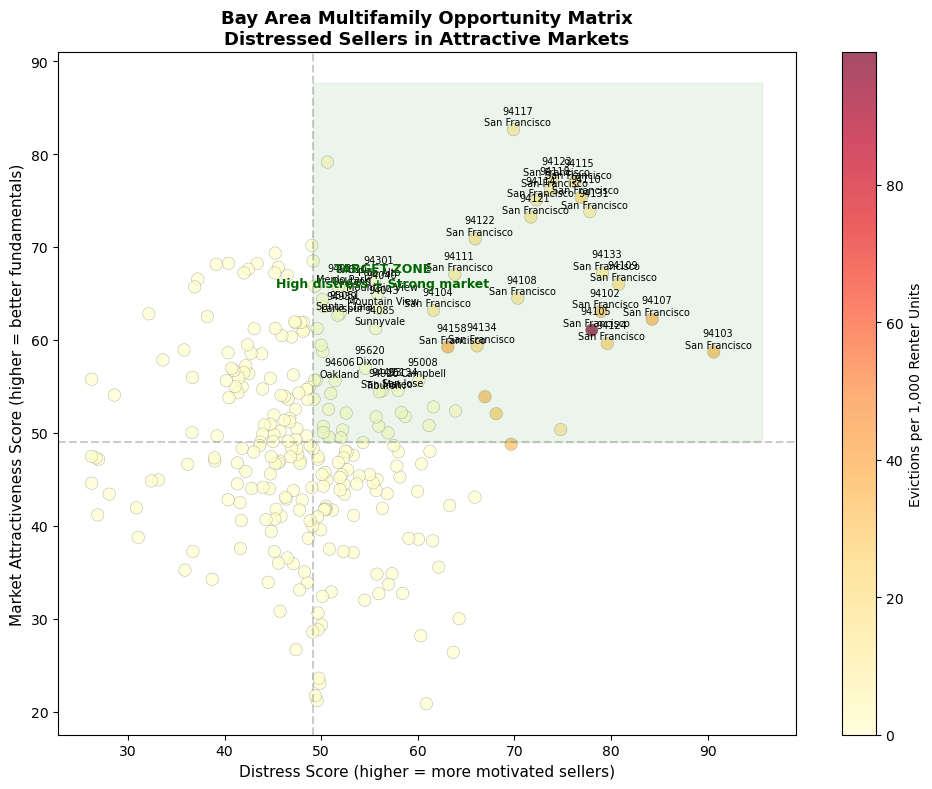


Top target zips (high distress + high market quality):
zip_code          City  distress_score  mkt_score
   94103 San Francisco       90.647810  58.704380
   94107 San Francisco       84.270073  62.226277
   94109 San Francisco       80.812044  66.003650
   94124 San Francisco       79.625912  59.607664
   94133 San Francisco       79.124088  67.189781
   94102 San Francisco       78.950730  63.056569
   94105 San Francisco       78.020073  61.058394
   94131 San Francisco       77.819343  73.795620
   94110 San Francisco       76.906934  75.328467
   94115 San Francisco       76.231752  76.989051


In [11]:
# The sweet spot: HIGH distress (deal flow) + HIGH market attractiveness
# These are markets where you can find distressed sellers in fundamentally good submarkets

combined = distress.merge(
    mkt[['zip_code','investment_score']].rename(columns={'investment_score':'mkt_score'}),
    on='zip_code', how='left'
)

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    combined['distress_score'],
    combined['mkt_score'],
    c=combined['eviction_rate_per_1k'],
    cmap='YlOrRd',
    s=80,
    alpha=0.7,
    edgecolors='gray',
    linewidth=0.3
)
plt.colorbar(scatter, label='Evictions per 1,000 Renter Units')

# Quadrant lines
ax.axvline(combined['distress_score'].median(), color='gray', linestyle='--', alpha=0.4)
ax.axhline(combined['mkt_score'].median(), color='gray', linestyle='--', alpha=0.4)

# Label top-right quadrant (high distress + high market quality)
target = combined[
    (combined['distress_score'] > combined['distress_score'].quantile(0.65)) &
    (combined['mkt_score'] > combined['mkt_score'].quantile(0.65))
]
for _, row in target.iterrows():
    ax.annotate(
        f"{row['zip_code']}\n{row['City']}",
        (row['distress_score'], row['mkt_score']),
        fontsize=7, ha='center',
        xytext=(3, 3), textcoords='offset points'
    )

# Shade target quadrant
ax.fill_betweenx(
    [combined['mkt_score'].median(), combined['mkt_score'].max() + 5],
    combined['distress_score'].median(),
    combined['distress_score'].max() + 5,
    alpha=0.08, color='green'
)
ax.text(
    combined['distress_score'].quantile(0.80),
    combined['mkt_score'].quantile(0.90),
    'TARGET ZONE\nHigh distress + Strong market',
    fontsize=9, color='darkgreen', fontweight='bold', ha='center'
)

ax.set_xlabel('Distress Score (higher = more motivated sellers)', fontsize=11)
ax.set_ylabel('Market Attractiveness Score (higher = better fundamentals)', fontsize=11)
ax.set_title('Bay Area Multifamily Opportunity Matrix\nDistressed Sellers in Attractive Markets', 
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(OUT / 'charts/opportunity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop target zips (high distress + high market quality):')
target_sorted = combined[
    (combined['distress_score'] > combined['distress_score'].quantile(0.65)) &
    (combined['mkt_score'] > combined['mkt_score'].quantile(0.65))
].sort_values('distress_score', ascending=False)
print(target_sorted[['zip_code','City','distress_score','mkt_score']].head(10).to_string(index=False))

In [12]:
# Export distress rankings
distress_export = distress.merge(
    mkt[['zip_code','investment_score']].rename(columns={'investment_score':'mkt_score'}),
    on='zip_code', how='left'
)
distress_export.to_csv(OUT / 'tables/distress_scores_ranked.csv', index=False)
print(f'Saved distress scores to outputs/tables/distress_scores_ranked.csv')

Saved distress scores to outputs/tables/distress_scores_ranked.csv
